<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 1 - Phase 1 - Claudia

## Import `music_videos.ndjson` into a DataFrame

In [1]:
import pandas as pd
df_music_videos = pd.read_json("corpus/00_sources/music_videos.ndjson", lines=True)

df_music_videos

,id,url,title,description,language,uploader,duration,upload_date,error
0,4xqo7D2k8HM,https://www.youtube.com/watch?v=4xqo7D2k8HM,Imagine Dragons - Believer (Live in Vegas),Watch Imagine Dragons Live in Vegas on Hulu: \...,NaN,ImagineDragons,280.0,20230720.0,NaN
1,nyuo9-OjNNg,https://www.youtube.com/watch?v=nyuo9-OjNNg,I Wanna Be Yours,Provided to YouTube by Domino\n\nI Wanna Be Yo...,NaN,Official Arctic Monkeys,184.0,20141209.0,NaN
2,mRD0-GxqHVo,https://www.youtube.com/watch?v=mRD0-GxqHVo,Glass Animals - Heat Waves (Official Video),I LOVE YOU SO F***ING MUCH.\nOur fourth studio...,NaN,Glass Animals,235.0,20200629.0,NaN
3,V1Pl8CzNzCw,https://www.youtube.com/watch?v=V1Pl8CzNzCw,"Billie Eilish, Khalid - lovely",Listen to “lovely” (with Khalid): http://smart...,NaN,Billie Eilish,201.0,20180426.0,NaN
4,yKNxeF4KMsY,https://www.youtube.com/watch?v=yKNxeF4KMsY,Coldplay - Yellow (Official Video),Coldplay's tenth studio album Moon Music avail...,NaN,Coldplay,272.0,20110530.0,NaN
...,...,...,...,...,...,...,...,...,...
1006,Er9xGRolrT4,https://www.youtube.com/watch?v=Er9xGRolrT4,Chic - Good Times (Atlantic Records 1979),"""Good Times"" is a 1979 song composed by Bernar...",en,DiscoSaturdayNightTV,503.0,20141129.0,NaN
1007,Wxx_2q409oY,https://www.youtube.com/watch?v=Wxx_2q409oY,Vertical Horizon - Everything You Want 1999,Vertical Horizon - Everything You Want 1999\nR...,NaN,Melopsittacus undulatus,259.0,20160619.0,NaN
1008,UVwKxz0e2sE,https://www.youtube.com/watch?v=UVwKxz0e2sE,Tommy Tutone - 867-5309 / Jenny (Lyrics HD),"Listen to ""867-5309 / Jenny"" by Tommy Tutone, ...",NaN,Song Lyrics HD,236.0,20210217.0,NaN
1009,j2F4INQFjEI,https://www.youtube.com/watch?v=j2F4INQFjEI,Belinda Carlisle - Heaven Is A Place On Earth ...,Official 4K Remastered Music Video for ‘Heaven...,NaN,Belinda Carlisle,244.0,20130522.0,NaN


## Create `transcript_word_count` column and replace the `error` column with a boolean indicating whether the video is available

In [2]:
import os
import numpy as np

TRANSCRIPTS_DIR = "corpus/02_music_videos_transcripts_gemini"

def get_transcript_word_count(video_id):
    if not isinstance(video_id, str):
        return 0

    filepath = os.path.join(TRANSCRIPTS_DIR, f"{video_id}.txt")

    if os.path.exists(filepath):
        with open(filepath, "r", encoding="utf-8") as f:
            return len(f.read().split())

    return 0

df_music_videos_dataset = df_music_videos.copy()

df_music_videos_dataset["available"] = df_music_videos_dataset["error"].isna()
df_music_videos_dataset = df_music_videos_dataset.drop(columns=["error"])

available_mask = df_music_videos_dataset["available"]

df_music_videos_dataset["transcript_word_count"] = pd.NA
df_music_videos_dataset.loc[available_mask, "transcript_word_count"] = [
    get_transcript_word_count(video_id)
    for video_id in df_music_videos_dataset.loc[available_mask, "id"]
]
df_music_videos_dataset["transcript_word_count"] = (
    df_music_videos_dataset["transcript_word_count"]
    .astype("Int64")
)

df_music_videos_dataset

,id,url,title,description,language,uploader,duration,upload_date,available,transcript_word_count
0,4xqo7D2k8HM,https://www.youtube.com/watch?v=4xqo7D2k8HM,Imagine Dragons - Believer (Live in Vegas),Watch Imagine Dragons Live in Vegas on Hulu: \...,NaN,ImagineDragons,280.0,20230720.0,True,407
1,nyuo9-OjNNg,https://www.youtube.com/watch?v=nyuo9-OjNNg,I Wanna Be Yours,Provided to YouTube by Domino\n\nI Wanna Be Yo...,NaN,Official Arctic Monkeys,184.0,20141209.0,True,228
2,mRD0-GxqHVo,https://www.youtube.com/watch?v=mRD0-GxqHVo,Glass Animals - Heat Waves (Official Video),I LOVE YOU SO F***ING MUCH.\nOur fourth studio...,NaN,Glass Animals,235.0,20200629.0,True,389
3,V1Pl8CzNzCw,https://www.youtube.com/watch?v=V1Pl8CzNzCw,"Billie Eilish, Khalid - lovely",Listen to “lovely” (with Khalid): http://smart...,NaN,Billie Eilish,201.0,20180426.0,True,176
4,yKNxeF4KMsY,https://www.youtube.com/watch?v=yKNxeF4KMsY,Coldplay - Yellow (Official Video),Coldplay's tenth studio album Moon Music avail...,NaN,Coldplay,272.0,20110530.0,True,200
...,...,...,...,...,...,...,...,...,...,...
1006,Er9xGRolrT4,https://www.youtube.com/watch?v=Er9xGRolrT4,Chic - Good Times (Atlantic Records 1979),"""Good Times"" is a 1979 song composed by Bernar...",en,DiscoSaturdayNightTV,503.0,20141129.0,True,359
1007,Wxx_2q409oY,https://www.youtube.com/watch?v=Wxx_2q409oY,Vertical Horizon - Everything You Want 1999,Vertical Horizon - Everything You Want 1999\nR...,NaN,Melopsittacus undulatus,259.0,20160619.0,True,330
1008,UVwKxz0e2sE,https://www.youtube.com/watch?v=UVwKxz0e2sE,Tommy Tutone - 867-5309 / Jenny (Lyrics HD),"Listen to ""867-5309 / Jenny"" by Tommy Tutone, ...",NaN,Song Lyrics HD,236.0,20210217.0,True,186
1009,j2F4INQFjEI,https://www.youtube.com/watch?v=j2F4INQFjEI,Belinda Carlisle - Heaven Is A Place On Earth ...,Official 4K Remastered Music Video for ‘Heaven...,NaN,Belinda Carlisle,244.0,20130522.0,True,304


## Descriptive statistics on the `transcript_word_count` column

In [3]:
df_music_videos_dataset["transcript_word_count"].describe()

count      1000.0
mean      317.362
std      166.9937
min           2.0
25%         202.0
50%         278.5
75%         380.0
max        1414.0
Name: transcript_word_count, dtype: Float64

## Boxplot and Interquartile Range (IQR) for `transcript_word_count`

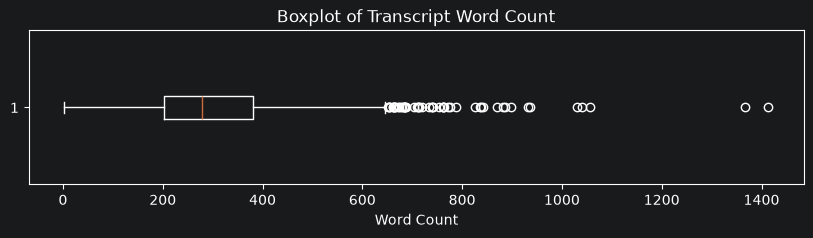

Q1 (25th percentile): 202
Q3 (75th percentile): 380
IQR: 178
Lower Bound (Non-outlier): -65.0
Upper Bound (Non-outlier): 647.0
Videos within the Non Outlier Range = 947
Videos within the IQR (504):
- I Wanna Be Yours: https://www.youtube.com/watch?v=nyuo9-OjNNg
- Billie Eilish - BIRDS OF A FEATHER (Official Music Video): https://www.youtube.com/watch?v=V9PVRfjEBTI
- Lady Gaga, Bruno Mars - Die With A Smile (Official Music Video): https://www.youtube.com/watch?v=kPa7bsKwL-c
- Vance Joy - 'Riptide' Official Video: https://www.youtube.com/watch?v=uJ_1HMAGb4k
- Eagles - Hotel California (Live 1977) (Official Video) [HD]: https://www.youtube.com/watch?v=09839DpTctU
- Queen - Don't Stop Me Now (Official Video): https://www.youtube.com/watch?v=HgzGwKwLmgM
- Queen and David Bowie - Under Pressure (Official Video): https://www.youtube.com/watch?v=a01QQZyl-_I
- AC/DC - Thunderstruck (Official Video): https://www.youtube.com/watch?v=v2AC41dglnM
- Elvis Presley - Burning Love (Aloha From Hawaii, L

In [4]:
import matplotlib.pyplot as plt

# Calculate Q1, Q3, and IQR for transcript_word_count
Q1 = df_music_videos_dataset['transcript_word_count'].quantile(0.25)
Q3 = df_music_videos_dataset['transcript_word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Plot the boxplot
plt.figure(figsize=(10, 2))
plt.boxplot(df_music_videos_dataset['transcript_word_count'].dropna(), orientation='horizontal')
plt.title('Boxplot of Transcript Word Count')
plt.xlabel('Word Count')
plt.show()

# Print the calculated quantities
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound (Non-outlier): {lower_bound}")
print(f"Upper Bound (Non-outlier): {upper_bound}")

# Create boolean columns
within_iqr = (df_music_videos_dataset['transcript_word_count'] >= Q1) & (df_music_videos_dataset['transcript_word_count'] <= Q3)
within_non_outlier_range = (df_music_videos_dataset['transcript_word_count'] >= lower_bound) & (df_music_videos_dataset['transcript_word_count'] <= upper_bound)

# Insert the columns before 'available'
if 'within_iqr' not in df_music_videos_dataset.columns:
    available_idx = df_music_videos_dataset.columns.get_loc('available')
    df_music_videos_dataset.insert(available_idx, 'within_iqr', within_iqr)
    df_music_videos_dataset.insert(available_idx + 1, 'within_non_outlier_range', within_non_outlier_range)

# List the url and title of the music videos that fall within the IQR
within_iqr_videos = df_music_videos_dataset[df_music_videos_dataset['within_iqr']][['title', 'url']]
within_non_outlier_range_videos = df_music_videos_dataset[df_music_videos_dataset['within_non_outlier_range']][['title', 'url']]
print(f"Videos within the Non Outlier Range = {len(within_non_outlier_range_videos)}")
print(f"Videos within the IQR ({len(within_iqr_videos)}):")
for index, row in within_iqr_videos.iterrows():
    print(f"- {row['title']}: {row['url']}")

## Export `df_music_videos_dataset` into NDJSON, TSV and XLSX formats

In [5]:
column_list = [
    'id',
    'url',
    'title',
    'description',
    'language',
    'uploader',
    'duration',
    'upload_date',
    'transcript_word_count',
    'within_iqr',
    'within_non_outlier_range',
    'available'
]

df_music_videos_dataset[column_list].to_json('corpus/00_sources/music_videos_dataset.ndjson', orient='records', lines=True)
df_music_videos_dataset[column_list].to_csv('corpus/00_sources/music_videos_dataset.tsv', sep='	', index=False)
df_music_videos_dataset[column_list].to_excel('corpus/00_sources/music_videos_dataset.xlsx', index=False)